In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
# Parameters
# ------ Configuration Parameters (can be overridden by papermill) ------
model_name = "gru"  # Options: gru, transformer, gru_transformer, mamba
num_epochs = 30
TICKER = "LCID"  # Single-run ticker
PREPROCESSING_CONTRACT_VERSION = 1
MAX_SAMPLES_PER_ORDER = 100
SPLIT_CAP_RANDOM_SEED = 4718
NUM_TIME_STEPS = 30
# -----------------------------------------------------------------------

# Standardized Dynamic DeepHit Baseline (Order-Updating Framework)

## 1. Import Required Libraries

In [3]:
import importlib
import os
import subprocess
import sys

MAMBA_REQ = "mamba-ssm==2.3.1"
CAUSAL_REQ = "causal-conv1d==1.6.1"
EINOPS_REQ = "einops>=0.7"

# Keep this False for normal runs. Set True only once if your env is missing packages.
AUTO_INSTALL_MAMBA_IN_ENV = False


def _module_exists(module_name: str) -> bool:
    try:
        return importlib.util.find_spec(module_name) is not None
    except Exception:
        return False


def _safe_import_version(module_name: str) -> tuple[bool, str | None, str | None]:
    """Return (ok, version, error_message) without crashing the cell."""
    try:
        module = importlib.import_module(module_name)
        version = getattr(module, "__version__", "unknown")
        return True, str(version), None
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"


print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", ""))

have_causal = _module_exists("causal_conv1d")
have_mamba = _module_exists("mamba_ssm")

if not (have_causal and have_mamba) and AUTO_INSTALL_MAMBA_IN_ENV:
    print("Installing mamba dependencies into active environment...")
    try:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "pip",
            "setuptools",
            "wheel",
            "ninja",
            EINOPS_REQ,
        ])
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "--no-build-isolation",
            "--upgrade",
            CAUSAL_REQ,
            MAMBA_REQ,
        ])
    except subprocess.CalledProcessError as exc:
        print(f"Auto-install failed: {exc}")

causal_ok, causal_ver, causal_err = _safe_import_version("causal_conv1d")
mamba_ok, mamba_ver, mamba_err = _safe_import_version("mamba_ssm")

print("causal_conv1d:", causal_ver if causal_ok else f"broken ({causal_err})")
print("mamba_ssm:", mamba_ver if mamba_ok else f"broken ({mamba_err})")

if not (causal_ok and mamba_ok):
    print("\nMamba dependencies are missing or broken in this kernel environment.")
else:
    print("Mamba dependencies are ready from the active environment (no per-run install needed).")

Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
CONDA_DEFAULT_ENV: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob


causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Mamba dependencies are ready from the active environment (no per-run install needed).


In [4]:
from __future__ import annotations

import gc
import json
import math
import os
import pickle
import random
import sys
import warnings
from copy import deepcopy
from datetime import datetime
from pathlib import Path

# Use the active kernel environment as the source of truth (no scratch package path injection).
active_conda_env = (os.environ.get("CONDA_DEFAULT_ENV", "") or "").strip()
active_env_name = Path(active_conda_env).name if active_conda_env else ""
is_lob_env = active_conda_env == "lob" or active_env_name == "lob"
if not is_lob_env:
    print(
        "Warning: kernel is not using conda env 'lob'. "
        f"Current env: {active_conda_env or 'unknown'}"
    )

# Ensure project root is importable regardless of the notebook launch directory.
repo_root_candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
for candidate in repo_root_candidates:
    if (candidate / "src").exists():
        repo_root = candidate.resolve()
        if str(repo_root) not in sys.path:
            sys.path.insert(0, str(repo_root))
        break
else:
    raise RuntimeError(
        "Could not locate project root containing 'src'. "
        f"Checked: {[str(p.resolve()) for p in repo_root_candidates]}"
    )

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
try:
    import torch
except RuntimeError as exc:
    if "already has a docstring" in str(exc):
        raise RuntimeError("PyTorch import state in this kernel is corrupted. Restart the kernel, rerun Cell 4, then rerun Cell 5.") from exc
    raise

from pycox.evaluation import EvalSurv
from pycox.models import DeepHit

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
 )
from src.notebook_data import (
    apply_dynamic_normalizer,
    build_order_batch_indices,
    materialize_dynamic_samples_from_manifest,
    select_manifest_indices_by_source_rows,
 )
from src.notebook_evaluation import standard_brier_score, uninformed_brier_score
from src.notebook_losses import dynamic_deephit_total_loss

warnings.filterwarnings("ignore", category=FutureWarning)

slurm_job_id = (
    os.environ.get("SLURM_JOB_ID")
    or os.environ.get("SLURM_JOBID")
    or os.environ.get("SLURM_ARRAY_JOB_ID")
    or ""
 ).strip()

JOB_LOG_FILE = os.environ.get("NOTEBOOK_JOB_LOG", "").strip()
if not JOB_LOG_FILE and slurm_job_id:
    JOB_LOG_FILE = str(Path("logs") / f"notebook_{slurm_job_id}.log")
if JOB_LOG_FILE:
    Path(JOB_LOG_FILE).parent.mkdir(parents=True, exist_ok=True)


def job_log(message: str) -> None:
    ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    line = f"[{ts}] {message}"

    # Print once to notebook output to avoid duplicated lines.
    print(line, flush=True)

    if JOB_LOG_FILE:
        try:
            with open(JOB_LOG_FILE, "a", encoding="utf-8") as f:
                f.write(line + "\n")
        except Exception as exc:
            print(f"[job_log warning] failed to write {JOB_LOG_FILE}: {exc}", file=sys.stderr, flush=True)


def gpu_mem_log(prefix: str = "GPU") -> None:
    if torch.cuda.is_available():
        allocated_gb = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved_gb = torch.cuda.memory_reserved() / (1024 ** 3)
        job_log(f"{prefix} memory: allocated={allocated_gb:.2f} GiB, reserved={reserved_gb:.2f} GiB")


print("PyTorch:", torch.__version__)
print("PyTorch loaded from:", Path(torch.__file__).resolve())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
job_log("Notebook environment initialization complete")
if JOB_LOG_FILE:
    print(f"Batch log file: {JOB_LOG_FILE}")

if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.6.0+cu124
PyTorch loaded from: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/lib/python3.11/site-packages/torch/__init__.py
Device: cuda
[2026-04-23 07:23:57] Notebook environment initialization complete
Batch log file: logs/notebook_40224577.log


In [5]:
# Force reload of src models/data modules to pick up code changes.
for mod_name in list(sys.modules):
    if mod_name == "src" or mod_name == "src.notebook_data" or mod_name.startswith("src.models"):
        del sys.modules[mod_name]

from src.models import (
    DeepHitMambaCompeting,
    DeepHitRNNCompeting,
    DeepHitRNNTransformerCompeting,
    DeepHitTransformerCompeting,
 )

# Re-import with updated preprocessed-artifact runtime APIs.
from src.notebook_data import (
    apply_dynamic_normalizer,
    build_order_batch_indices,
    materialize_dynamic_samples_from_manifest,
    select_manifest_indices_by_source_rows,
 )

print("Modules reloaded successfully (src.models + src.notebook_data)")

Modules reloaded successfully (src.models + src.notebook_data)


## 2. Load and Explore the Dataset

In [6]:
DATASET_BASE_DIR = Path("/ocean/projects/cis260122p/shared/data/datasets")
DATASET_STEM_TEMPLATE = "labeled_dataset_XNAS_ITCH_{ticker}_mbo_20251001_20260101"

REQUIRED_RUNTIME_ARRAYS = [
    "train_sample_idx",
    "val_sample_idx",
    "Y_train_disc",
    "D_train_disc",
    "Y_val",
    "D_val",
    "Y_val_disc",
    "D_val_disc",
    "ORDER_KEYS_TRAIN",
    "ORDER_KEYS_VAL",
    "UPDATE_IDX_TRAIN",
    "UPDATE_IDX_VAL",
    "feat_mean",
    "feat_std",
    "time_grid",
]

In [7]:
# Verify mamba dependencies in the active kernel environment without crashing on import errors.
import importlib
import os
import sys


def _safe_import_status(module_name: str) -> tuple[bool, str | None, str | None]:
    try:
        module = importlib.import_module(module_name)
        return True, str(getattr(module, "__version__", "unknown")), None
    except Exception as exc:
        return False, None, f"{type(exc).__name__}: {exc}"


causal_ok, causal_ver, causal_err = _safe_import_status("causal_conv1d")
mamba_ok, mamba_ver, mamba_err = _safe_import_status("mamba_ssm")

print("Python:", sys.executable)
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", ""))
print("causal_conv1d:", causal_ver if causal_ok else f"broken ({causal_err})")
print("mamba_ssm:", mamba_ver if mamba_ok else f"broken ({mamba_err})")

if not (causal_ok and mamba_ok):
    print("\nMissing/broken mamba stack for this kernel.")
else:
    print("Mamba stack is healthy in this kernel.")

Python: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob/bin/python3.11
CONDA_DEFAULT_ENV: /ocean/projects/cis260122p/ccheung1/.conda_envs/lob
causal_conv1d: 1.6.1
mamba_ssm: 2.3.1
Mamba stack is healthy in this kernel.


In [8]:
from src.notebook_data import DynamicSampleManifest

def _ticker_paths(ticker_symbol: str) -> dict[str, Path]:
    symbol = str(ticker_symbol).upper()
    stem = DATASET_STEM_TEMPLATE.format(ticker=symbol)
    return {
        "dynamic_order_store": DATASET_BASE_DIR / f"{stem}_dynamic_order_store.pkl",
        "dynamic_manifest": DATASET_BASE_DIR / f"{stem}_dynamic_sample_manifest.parquet",
        "dynamic_manifest_meta": DATASET_BASE_DIR / f"{stem}_dynamic_manifest_meta.json",
        "dynamic_preprocessed": DATASET_BASE_DIR / f"{stem}_dynamic_preprocessed.npz",
    }


def _load_runtime_npz(npz_path: Path) -> dict[str, np.ndarray]:
    with np.load(npz_path, allow_pickle=False) as data:
        return {k: data[k] for k in data.files}


def _load_dynamic_manifest(manifest_path: Path) -> DynamicSampleManifest:
    manifest_df = pd.read_parquet(manifest_path)
    return DynamicSampleManifest(
        order_ptr=manifest_df["order_ptr"].to_numpy(dtype=np.int32, copy=False),
        end_idx=manifest_df["end_idx"].to_numpy(dtype=np.int32, copy=False),
        y=manifest_df["y"].to_numpy(dtype=np.float32, copy=False),
        d=manifest_df["d"].to_numpy(dtype=np.int64, copy=False),
        order_ids=manifest_df["order_ids"].to_numpy(dtype=np.int64, copy=False),
        entry_times=manifest_df["entry_times"].to_numpy(dtype=np.int64, copy=False),
        source_row_idx=manifest_df["source_row_idx"].to_numpy(dtype=np.int64, copy=False),
        update_idx=manifest_df["update_idx"].to_numpy(dtype=np.int32, copy=False),
    )


def _slice_manifest_arrays(sample_idx: np.ndarray):
    idx = np.asarray(sample_idx, dtype=np.int64)
    return (
        SAMPLE_MANIFEST.y[idx].astype(np.float32, copy=False),
        SAMPLE_MANIFEST.d[idx].astype(np.int64, copy=False),
        SAMPLE_MANIFEST.order_ids[idx].astype(np.int64, copy=False),
        SAMPLE_MANIFEST.source_row_idx[idx].astype(np.int64, copy=False),
        SAMPLE_MANIFEST.entry_times[idx].astype(np.int64, copy=False),
        SAMPLE_MANIFEST.update_idx[idx].astype(np.int64, copy=False),
    )



def _set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _per_order_instance_weights(order_keys: np.ndarray) -> np.ndarray:
    counts = pd.Series(order_keys).value_counts()
    return np.asarray([1.0 / counts[int(ok)] for ok in order_keys], dtype=np.float64)


def _dynamic_weighted_ctd_event(
    cif_event: np.ndarray,
    durations: np.ndarray,
    events: np.ndarray,
    event_code: int,
    update_idx: np.ndarray,
    time_grid_local: np.ndarray,
    instance_weight: np.ndarray,
    eps: float = 1e-12,
) -> float:
    n = len(durations)
    if n == 0:
        return float("nan")
    tau_idx = np.searchsorted(time_grid_local, durations, side="left")
    tau_idx = np.clip(tau_idx, 0, len(time_grid_local) - 1)
    num = 0.0
    den = 0.0
    for step in np.unique(update_idx):
        step_idx = np.where(update_idx == step)[0]
        if step_idx.size <= 1:
            continue
        anchors = step_idx[events[step_idx] == event_code]
        if anchors.size == 0:
            continue
        durations_step = durations[step_idx]
        pos_in_step = {idx: pos for pos, idx in enumerate(step_idx.tolist())}
        for i in anchors:
            i_pos = pos_in_step[int(i)]
            later_mask = durations_step > durations_step[i_pos]
            if not np.any(later_mask):
                continue
            tau_anchor = int(tau_idx[i])
            later_idx = step_idx[later_mask]
            s_i = float(cif_event[tau_anchor, i])
            s_j = cif_event[tau_anchor, later_idx]
            w_pair = instance_weight[i] * instance_weight[later_idx]
            concordant = (s_i > s_j).astype(np.float64)
            ties = (s_i == s_j).astype(np.float64)
            num += float(np.sum(w_pair * (concordant + 0.5 * ties)))
            den += float(np.sum(w_pair))
    if den <= eps:
        return float("nan")
    return num / den

ticker_symbol = str(TICKER).upper()
paths = _ticker_paths(ticker_symbol)
missing_files = [str(p) for p in paths.values() if not p.exists()]
if missing_files:
    raise FileNotFoundError(f"[{ticker_symbol}] Missing files:\n" + "\n".join(missing_files))

with open(paths["dynamic_order_store"], "rb") as f:
    ORDER_STORE = pickle.load(f)
SAMPLE_MANIFEST = _load_dynamic_manifest(paths["dynamic_manifest"])
with open(paths["dynamic_manifest_meta"], "r", encoding="utf-8") as f:
    manifest_meta = json.load(f)
runtime_npz = _load_runtime_npz(paths["dynamic_preprocessed"])

contract_version = int(manifest_meta.get("preprocessing_contract_version", -1))
if contract_version != PREPROCESSING_CONTRACT_VERSION:
    raise ValueError(
        f"[{ticker_symbol}] Preprocessing contract mismatch: "
        f"expected={PREPROCESSING_CONTRACT_VERSION}, found={contract_version}"
    )

preprocessing_config = manifest_meta.get("preprocessing_config")
if not isinstance(preprocessing_config, dict):
    raise ValueError(f"[{ticker_symbol}] Missing preprocessing_config in manifest metadata.")

if int(preprocessing_config.get("max_samples_per_source_row", -1)) != int(MAX_SAMPLES_PER_ORDER):
    raise ValueError(
        f"[{ticker_symbol}] max_samples_per_source_row mismatch: "
        f"notebook={MAX_SAMPLES_PER_ORDER}, artifact={preprocessing_config.get('max_samples_per_source_row')}"
    )

if int(preprocessing_config.get("split_cap_random_seed", -1)) != int(SPLIT_CAP_RANDOM_SEED):
    raise ValueError(
        f"[{ticker_symbol}] split_cap_random_seed mismatch: "
        f"notebook={SPLIT_CAP_RANDOM_SEED}, artifact={preprocessing_config.get('split_cap_random_seed')}"
    )

if int(preprocessing_config.get("num_time_steps", -1)) != int(NUM_TIME_STEPS):
    raise ValueError(
        f"[{ticker_symbol}] num_time_steps mismatch: "
        f"notebook={NUM_TIME_STEPS}, artifact={preprocessing_config.get('num_time_steps')}"
    )

missing_arrays = [name for name in REQUIRED_RUNTIME_ARRAYS if name not in runtime_npz]
if missing_arrays:
    raise ValueError(f"[{ticker_symbol}] Missing runtime arrays: {missing_arrays}")

train_sample_idx = runtime_npz["train_sample_idx"].astype(np.int64, copy=False)
val_sample_idx = runtime_npz["val_sample_idx"].astype(np.int64, copy=False)
Y_train_disc = runtime_npz["Y_train_disc"].astype(np.int64, copy=False)
D_train_disc = runtime_npz["D_train_disc"].astype(np.int64, copy=False)
Y_val = runtime_npz["Y_val"].astype(np.float32, copy=False)
D_val = runtime_npz["D_val"].astype(np.int64, copy=False)
Y_val_disc = runtime_npz["Y_val_disc"].astype(np.int64, copy=False)
D_val_disc = runtime_npz["D_val_disc"].astype(np.int64, copy=False)
ORDER_KEYS_TRAIN = runtime_npz["ORDER_KEYS_TRAIN"].astype(np.int64, copy=False)
ORDER_KEYS_VAL = runtime_npz["ORDER_KEYS_VAL"].astype(np.int64, copy=False)
UPDATE_IDX_TRAIN = runtime_npz["UPDATE_IDX_TRAIN"].astype(np.int64, copy=False)
UPDATE_IDX_VAL = runtime_npz["UPDATE_IDX_VAL"].astype(np.int64, copy=False)
feat_mean = runtime_npz["feat_mean"].astype(np.float32, copy=False)
feat_std = runtime_npz["feat_std"].astype(np.float32, copy=False)
time_grid = runtime_npz["time_grid"].astype(np.float32, copy=False)

if train_sample_idx.size == 0 or val_sample_idx.size == 0:
    raise ValueError(
        f"[{ticker_symbol}] Empty train/val samples in runtime NPZ: "
        f"train={train_sample_idx.size}, val={val_sample_idx.size}"
    )

feature_dim_total_check = int(ORDER_STORE.lob_dim + ORDER_STORE.tox_dim + 2)
if feat_mean.shape[-1] != feature_dim_total_check or feat_std.shape[-1] != feature_dim_total_check:
    raise ValueError(
        f"[{ticker_symbol}] Normalizer shape mismatch: feat_mean={feat_mean.shape}, "
        f"feat_std={feat_std.shape}, feature_dim_total={feature_dim_total_check}"
    )

n_train_orders = int(manifest_meta.get("n_train_orders", 0))
n_val_orders = int(manifest_meta.get("n_val_orders", 0))
n_test_orders = int(manifest_meta.get("n_test_orders", 0))
if n_train_orders <= 0 or n_val_orders <= 0 or n_test_orders <= 0:
    raise ValueError(
        f"[{ticker_symbol}] Invalid split order counts in metadata: "
        f"train={n_train_orders}, val={n_val_orders}, test={n_test_orders}"
    )

train_source_rows_full = np.arange(0, n_train_orders, dtype=np.int64)
val_source_rows = np.arange(n_train_orders, n_train_orders + n_val_orders, dtype=np.int64)
test_source_rows = np.arange(
    n_train_orders + n_val_orders,
    n_train_orders + n_val_orders + n_test_orders,
    dtype=np.int64,
)

train_sample_idx_full = select_manifest_indices_by_source_rows(SAMPLE_MANIFEST, train_source_rows_full)
val_sample_idx_full = select_manifest_indices_by_source_rows(SAMPLE_MANIFEST, val_source_rows)
test_sample_idx_full = select_manifest_indices_by_source_rows(SAMPLE_MANIFEST, test_source_rows)
test_sample_idx = test_sample_idx_full

if test_sample_idx.size == 0:
    raise ValueError(f"[{ticker_symbol}] No test samples found in manifest.")

Y_train, D_train, ORDER_IDS_TRAIN, _, ENTRY_TIMES_TRAIN, _ = _slice_manifest_arrays(train_sample_idx)
Y_val_manifest, D_val_manifest, ORDER_IDS_VAL, ORDER_KEYS_VAL, ENTRY_TIMES_VAL, UPDATE_IDX_VAL = _slice_manifest_arrays(val_sample_idx)
Y_test, D_test, ORDER_IDS_TEST, ORDER_KEYS_TEST, ENTRY_TIMES_TEST, UPDATE_IDX_TEST = _slice_manifest_arrays(test_sample_idx)

ORDER_TRAIN_WEIGHTS = _per_order_instance_weights(ORDER_KEYS_TRAIN)
ORDER_VAL_WEIGHTS = _per_order_instance_weights(ORDER_KEYS_VAL)

# Keep continuous val arrays from runtime NPZ as source-of-truth contract payload.
Y_val = Y_val.astype(np.float32, copy=False)
D_val = D_val.astype(np.int64, copy=False)

LEAD_TIME_BIN_EDGES = np.array([0.0, 1.0, 5.0, 15.0, 60.0], dtype=np.float64)
LEAD_TIME_BIN_LABELS = ["0-1s", "1-5s", "5-15s", "15-60s"]
LEAD_TIME_BIN_TEST = pd.cut(
    Y_test.astype(np.float64),
    bins=LEAD_TIME_BIN_EDGES,
    labels=LEAD_TIME_BIN_LABELS,
    include_lowest=True,
    right=True,
).astype(str).to_numpy()

Y_train_t = torch.tensor(Y_train_disc, dtype=torch.int64, device="cpu")
D_train_t = torch.tensor(D_train_disc, dtype=torch.int64, device="cpu")
Y_val_t = torch.tensor(Y_val_disc, dtype=torch.int64, device="cpu")
D_val_t = torch.tensor(D_val_disc, dtype=torch.int64, device="cpu")

ORDER_KEYS_TRAIN_t = torch.tensor(ORDER_KEYS_TRAIN, dtype=torch.int64, device="cpu")
ORDER_KEYS_VAL_t = torch.tensor(ORDER_KEYS_VAL, dtype=torch.int64, device="cpu")
UPDATE_IDX_TRAIN_t = torch.tensor(UPDATE_IDX_TRAIN, dtype=torch.int64, device="cpu")
UPDATE_IDX_VAL_t = torch.tensor(UPDATE_IDX_VAL, dtype=torch.int64, device="cpu")

TRAIN_SAMPLE_COUNT_FULL = int(train_sample_idx_full.shape[0])
VAL_SAMPLE_COUNT_FULL = int(val_sample_idx_full.shape[0])
TEST_SAMPLE_COUNT_FULL = int(test_sample_idx_full.shape[0])

TRAIN_SAMPLE_COUNT = int(train_sample_idx.shape[0])
VAL_SAMPLE_COUNT = int(val_sample_idx.shape[0])
TEST_SAMPLE_COUNT = int(test_sample_idx.shape[0])
FEATURE_DIM_TOTAL = int(ORDER_STORE.lob_dim + ORDER_STORE.tox_dim + 2)
SEQUENCE_LENGTH = int(ORDER_STORE.lookback_steps)
MATERIALIZE_CHUNK_SIZE = 1024

LOOKBACK_STEPS = int(ORDER_STORE.lookback_steps)
LOB_FEATURE_DIM = int(ORDER_STORE.lob_dim)
TOX_FEATURE_DIM = int(ORDER_STORE.tox_dim)
SEED = int(SPLIT_CAP_RANDOM_SEED)
_set_seed(SEED)
TRAIN_ORDER_SUBSAMPLE_FRACTION = float(preprocessing_config["train_order_subsample_fraction"])
TRAIN_ORDER_SUBSAMPLE_SEED = int(preprocessing_config["train_order_subsample_seed"])

train_order_ids = np.unique(ORDER_IDS_TRAIN).astype(np.int64)
val_order_ids = np.unique(ORDER_IDS_VAL).astype(np.int64)
test_order_ids = np.unique(ORDER_IDS_TEST).astype(np.int64)
train_order_ids_full = train_order_ids

output_steps = int(time_grid.shape[0])
feature_dim = FEATURE_DIM_TOTAL
seq_len = SEQUENCE_LENGTH
TICKER = ticker_symbol

print(f"Loaded preprocessed artifacts for {TICKER}")
print(f"Manifest samples: {len(SAMPLE_MANIFEST):,}")
print(f"Dynamic samples (used): train={TRAIN_SAMPLE_COUNT:,}, val={VAL_SAMPLE_COUNT:,}, test={TEST_SAMPLE_COUNT:,}")
print(f"Dynamic samples (full): train={TRAIN_SAMPLE_COUNT_FULL:,}, val={VAL_SAMPLE_COUNT_FULL:,}, test={TEST_SAMPLE_COUNT_FULL:,}")
print(f"feature_dim={FEATURE_DIM_TOTAL}, seq_len={SEQUENCE_LENGTH}, output_steps={output_steps}")
print(f"Random cap settings: train/val max_samples_per_order={MAX_SAMPLES_PER_ORDER}, seed={SPLIT_CAP_RANDOM_SEED}")

Loaded preprocessed artifacts for LCID
Manifest samples: 7,656,259
Dynamic samples (used): train=360,304, val=277,317, test=1,265,761
Dynamic samples (full): train=5,419,124, val=971,374, test=1,265,761
feature_dim=34, seq_len=500, output_steps=30
Random cap settings: train/val max_samples_per_order=100, seed=4718


### 2a. Recode Event Types: Competing Fill Risks

Dynamic-snapshot event distribution (from preprocessed manifest/runtime arrays):
  0: CENSORED             -   828551
  1: FAVORABLE_FILL       -   665495
  2: TOXIC_FILL           -   409336


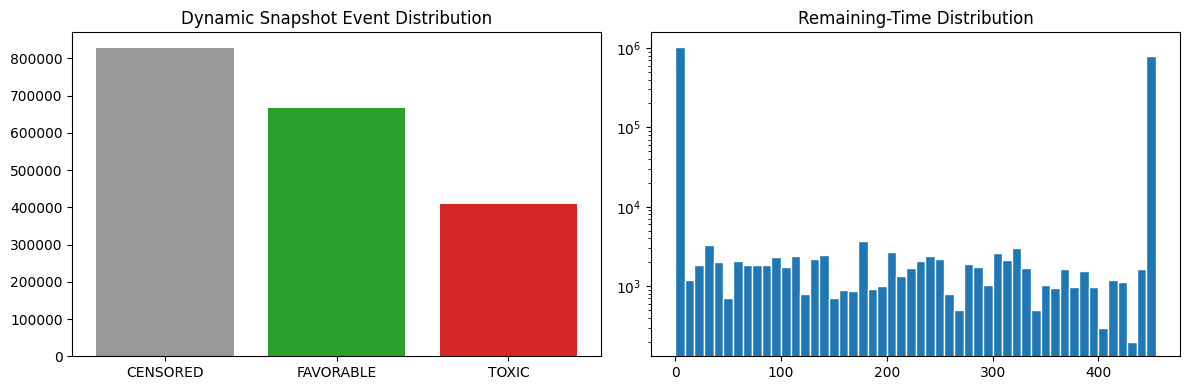

In [9]:
label_map = {0: "CENSORED", 1: "FAVORABLE_FILL", 2: "TOXIC_FILL"}
event_all = np.concatenate([D_train, D_val, D_test])
duration_all = np.concatenate([Y_train, Y_val, Y_test]).astype(np.float32, copy=False)
event_counts = pd.Series(event_all).value_counts().sort_index()

print("Dynamic-snapshot event distribution (from preprocessed manifest/runtime arrays):")
for code in sorted(event_counts.index):
    print(f"  {int(code)}: {label_map.get(int(code), f'UNKNOWN_{code}'):<20} - {int(event_counts[code]):>8}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(
    ["CENSORED", "FAVORABLE", "TOXIC"],
    [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)],
    color=["#999999", "#2ca02c", "#d62728"],
)
ax[0].set_title("Dynamic Snapshot Event Distribution")
ax[1].hist(duration_all, bins=50, color="#1f77b4", edgecolor="white")
ax[1].set_title("Remaining-Time Distribution")
ax[1].set_yscale("log")
plt.tight_layout()
plt.show()

## 3. Build Dynamic Training Samples
### 3a. Rolling Lookback Features and Remaining-Time Targets

In [10]:
print(
    f"Using precomputed dynamic manifest for {TICKER}: "
    f"lookback={LOOKBACK_STEPS}, lob_dim={LOB_FEATURE_DIM}, tox_dim={TOX_FEATURE_DIM}"
)
print(
    "Preprocessing config: "
    f"train_order_subsample_fraction={TRAIN_ORDER_SUBSAMPLE_FRACTION}, "
    f"max_samples_per_source_row={MAX_SAMPLES_PER_ORDER}, "
    f"split_cap_random_seed={SPLIT_CAP_RANDOM_SEED}, num_time_steps={NUM_TIME_STEPS}"
)
print(f"Time grid: {time_grid}")

Using precomputed dynamic manifest for LCID: lookback=500, lob_dim=20, tox_dim=12
Preprocessing config: train_order_subsample_fraction=0.3, max_samples_per_source_row=100, split_cap_random_seed=4718, num_time_steps=30
Time grid: [  0.          0.5182718   1.1436775   1.9302435   2.7889616   3.6486828
   4.7523293   5.948391    7.23972     8.75905    10.139983   11.813662
  13.671269   15.52052    17.722076   20.176378   23.243168   26.546814
  30.606993   35.59986    41.126514   47.416416   55.662      66.25693
  80.230774  102.0724    132.73158   178.78806   264.74127   454.45786  ]


### 3b. Train / Validation / Test Split by Order Entry Day
### 3c. Feature Normalisation
### 3d. Discretise Remaining Durations
### 3e. Build PyTorch Datasets with Order-Balancing Weights

In [11]:
# Data tensors and split metadata are loaded from preprocessed artifacts (no in-notebook resplitting).
train_order_instances = np.unique(ORDER_KEYS_TRAIN)
val_order_instances = np.unique(ORDER_KEYS_VAL)
test_order_instances = np.unique(ORDER_KEYS_TEST)

print(f"Order-instance split: train={len(train_order_instances):,}, val={len(val_order_instances):,}, test={len(test_order_instances):,}")
print(f"Raw order_id unique counts: train={len(np.unique(train_order_ids)):,}, val={len(np.unique(val_order_ids)):,}, test={len(np.unique(test_order_ids)):,}")
print(f"Dynamic samples (full): train={TRAIN_SAMPLE_COUNT_FULL:,}, val={VAL_SAMPLE_COUNT_FULL:,}, test={TEST_SAMPLE_COUNT_FULL:,}")
print(f"Dynamic samples (used): train={TRAIN_SAMPLE_COUNT:,}, val={VAL_SAMPLE_COUNT:,}, test={TEST_SAMPLE_COUNT:,} (test is full-length)")
print(f"Random cap settings: train/val max_samples_per_order={MAX_SAMPLES_PER_ORDER}, seed={SPLIT_CAP_RANDOM_SEED}")
print(f"Output time steps: {output_steps}")
print(f"Time grid: {time_grid}")
print("Stored dynamic test metadata: ORDER_IDS_TEST, ORDER_KEYS_TEST, UPDATE_IDX_TEST, ENTRY_TIMES_TEST, LEAD_TIME_BIN_TEST")

train_samples_per_order = pd.Series(ORDER_KEYS_TRAIN).value_counts().to_numpy()
if train_samples_per_order.size > 0:
    print(
        "Train samples/order-instance stats (capped):",
        {
            "min": int(train_samples_per_order.min()),
            "p50": int(np.percentile(train_samples_per_order, 50)),
            "p90": int(np.percentile(train_samples_per_order, 90)),
            "max": int(train_samples_per_order.max()),
        },
    )
else:
    print("Train order stats unavailable: empty training split.")

test_samples_per_order = pd.Series(ORDER_KEYS_TEST).value_counts().to_numpy()
if test_samples_per_order.size > 0:
    print(
        "Test samples/order-instance stats (full-length):",
        {
            "min": int(test_samples_per_order.min()),
            "p50": int(np.percentile(test_samples_per_order, 50)),
            "p90": int(np.percentile(test_samples_per_order, 90)),
            "max": int(test_samples_per_order.max()),
        },
    )

Order-instance split: train=12,900, val=10,000, test=9,000
Raw order_id unique counts: train=2,835, val=3,000, test=4,000
Dynamic samples (full): train=5,419,124, val=971,374, test=1,265,761
Dynamic samples (used): train=360,304, val=277,317, test=1,265,761 (test is full-length)
Random cap settings: train/val max_samples_per_order=100, seed=4718
Output time steps: 30
Time grid: [  0.          0.5182718   1.1436775   1.9302435   2.7889616   3.6486828
   4.7523293   5.948391    7.23972     8.75905    10.139983   11.813662
  13.671269   15.52052    17.722076   20.176378   23.243168   26.546814
  30.606993   35.59986    41.126514   47.416416   55.662      66.25693
  80.230774  102.0724    132.73158   178.78806   264.74127   454.45786  ]
Stored dynamic test metadata: ORDER_IDS_TEST, ORDER_KEYS_TEST, UPDATE_IDX_TEST, ENTRY_TIMES_TEST, LEAD_TIME_BIN_TEST
Train samples/order-instance stats (capped): {'min': 1, 'p50': 10, 'p90': 100, 'max': 100}
Test samples/order-instance stats (full-length): 

## 4. Define the Dynamic DeepHit Architecture (Imported from src/models)

Set `MODEL_NAME` to one of:
- `gru`
- `gru_transformer`
- `transformer`
- `mamba`

In [12]:
MODEL_NAME = model_name
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

ALPHA = 8.0
SIGMA = 0.1  # Ranking-scale parameter in L2.
LEARNING_RATE = 1e-4
BATCH_SIZE = 1024  # Inference/evaluation batch size.

USE_AMP = device.type == "cuda"
AMP_DTYPE = torch.float16

ORDERS_PER_BATCH = 64

ORDER_BATCH_SEED = SEED
NUM_EPOCHS = num_epochs
EARLY_STOP_PATIENCE = max(3, math.ceil(0.2 * NUM_EPOCHS))
BETA_L3 = 0.1
AUX_TARGET_DIM = LOB_FEATURE_DIM + TOX_FEATURE_DIM  # Exclude side and mask channels.

feature_dim = FEATURE_DIM_TOTAL
seq_len = SEQUENCE_LENGTH

_set_seed(SEED)

if MODEL_NAME == "gru":
    base_net = DeepHitRNNCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=160,
        num_layers=1,
        rnn_dropout=0.2,
        fc_hidden=int(160 * 1.75),
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "gru_transformer":
    base_net = DeepHitRNNTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=2,
        rnn_dropout=0.2,
        transformer_layers=2,
        transformer_heads=4,
        transformer_ff_dim=192,
        transformer_dropout=0.1,
        max_seq_len=seq_len,
        fc_hidden=128,
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "transformer":
    base_net = DeepHitTransformerCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_layers=4,
        num_heads=4,
        transformer_ff_dim=int(96 * 3.0),
        transformer_dropout=0.1,
        max_seq_len=seq_len,
        fc_hidden=int(96 * 1.75),
        fc_dropout=0.2,
    ).to(device)
elif MODEL_NAME == "mamba":
    base_net = DeepHitMambaCompeting(
        num_features=feature_dim,
        num_events=NUM_COMPETING_EVENTS,
        num_time_steps=output_steps,
        hidden_size=96,
        num_mamba_layers=2,
        d_state=8,
        d_conv=4,
        expand=4,
        mamba_dropout=0.15,
        fc_hidden=int(96 * 1.75),
        fc_dropout=0.2,
    ).to(device)
else:
    raise ValueError(f"Unknown MODEL_NAME: {MODEL_NAME}")

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Model: {MODEL_NAME}")
print(f"Input shape: ({TRAIN_SAMPLE_COUNT}, {seq_len}, {feature_dim})")
print(f"Output shape: ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params: {total_params:,}")
print(f"Training orders/batch: {ORDERS_PER_BATCH}")
print(f"AMP enabled: {USE_AMP} (dtype={AMP_DTYPE})")
print(f"L2 sigma: {SIGMA}")
print(f"L3 beta: {BETA_L3}")
print(f"Aux target dim: {AUX_TARGET_DIM}")

Model: gru
Input shape: (360304, 500, 34)
Output shape: (2, 30)
Trainable params: 264,973
Training orders/batch: 64
AMP enabled: True (dtype=torch.float16)
L2 sigma: 0.1
L3 beta: 0.1
Aux target dim: 32


## 4b. Experiment Tracking (Weights & Biases)

W&B login credentials are loaded from `.env` (`WANDB_ENTITY`, `WANDB_API_KEY`).

In [13]:
import wandb
from dotenv import find_dotenv, load_dotenv


dotenv_path = find_dotenv(filename=".env", usecwd=True)
if dotenv_path:
    load_dotenv(dotenv_path=dotenv_path, override=False)
else:
    load_dotenv(override=False)

WANDB_ENABLE = True
WANDB_PROJECT = "final"
WANDB_MODE = "online"
WANDB_ENTITY = os.environ.get("WANDB_ENTITY", "").strip()
WANDB_API_KEY = os.environ.get("WANDB_API_KEY", "").strip()
WANDB_RESUME_RUN_ID = "9pvvdm0w"

if WANDB_RESUME_RUN_ID:
    WANDB_RUN_NAME = None
    WANDB_RUN_ID = WANDB_RESUME_RUN_ID
else:
    WANDB_RUN_NAME = f"dynamic_deephit_{MODEL_NAME}_{TICKER}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
    WANDB_RUN_ID = None

wandb_run = None
if WANDB_ENABLE:
    if not WANDB_ENTITY:
        raise ValueError("WANDB_ENTITY is missing. Set it in .env (example: WANDB_ENTITY=your_wandb_team_or_username).")
    if not WANDB_API_KEY:
        raise ValueError("WANDB_API_KEY is missing. Set it in .env with your W&B API key.")

    os.environ["WANDB_API_KEY"] = WANDB_API_KEY
    wandb.login(key=WANDB_API_KEY, relogin=True)

    wandb_config = {
        "model_name": MODEL_NAME,
        "num_competing_events": NUM_COMPETING_EVENTS,
        "event_names": EVENT_NAMES,
        "alpha": ALPHA,
        "sigma": SIGMA,
        "beta_l3": BETA_L3,
        "learning_rate": LEARNING_RATE,
        "batch_size_eval": BATCH_SIZE,
        "orders_per_batch": ORDERS_PER_BATCH,
        "num_epochs": NUM_EPOCHS,
        "early_stop_patience": EARLY_STOP_PATIENCE,
        "use_amp": USE_AMP,
        "amp_dtype": str(AMP_DTYPE),
        "lookback_steps": LOOKBACK_STEPS,
        "lob_feature_dim": LOB_FEATURE_DIM,
        "tox_feature_dim": TOX_FEATURE_DIM,
        "train_samples": TRAIN_SAMPLE_COUNT,
        "val_samples": VAL_SAMPLE_COUNT,
        "test_samples": TEST_SAMPLE_COUNT,
        "output_steps": output_steps,
        "seed": SEED,
        "subsample": {
            "enabled": TRAIN_ORDER_SUBSAMPLE_FRACTION < 1.0,
            "fraction": TRAIN_ORDER_SUBSAMPLE_FRACTION,
            "seed": TRAIN_ORDER_SUBSAMPLE_SEED,
        },
    }

    init_kwargs = {
        "project": WANDB_PROJECT,
        "entity": WANDB_ENTITY,
        "config": wandb_config,
        "mode": WANDB_MODE,
        "reinit": False,
    }

    if WANDB_RESUME_RUN_ID:
        init_kwargs["id"] = WANDB_RESUME_RUN_ID
        init_kwargs["resume"] = "allow"
        job_log(f"Resuming W&B run: {WANDB_RESUME_RUN_ID}")
    else:
        init_kwargs["name"] = WANDB_RUN_NAME
        job_log(f"Starting new W&B run: {WANDB_RUN_NAME}")

    wandb_run = wandb.init(**init_kwargs)
    wandb.define_metric("epoch")
    wandb.define_metric("train/*", step_metric="epoch")
    wandb.define_metric("val/*", step_metric="epoch")
    wandb.define_metric("train/lr", step_metric="epoch")
    print(f"W&B initialized: entity={WANDB_ENTITY}, project={WANDB_PROJECT}, run_id={wandb_run.id}")
else:
    print("W&B logging is disabled for this run.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /jet/home/ccheung1/.netrc
wandb: Currently logged in as: angus4718 (lob-deep-survival-analysis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[2026-04-23 07:24:43] Starting new W&B run: dynamic_deephit_gru_LCID_20260423_072442


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


W&B initialized: entity=lob-deep-survival-analysis, project=final, run_id=9pvvdm0w


## 5. Train the DeepHit Model

In [14]:
gc.collect()

286

In [ ]:
from tqdm.auto import tqdm

In [16]:
# Clear stale GPU allocations from prior interrupted runs before re-launching training.
stale_vars = [
    "X_b", "Y_b", "D_b", "O_b", "U_b",
    "X_b_cpu", "Y_b_cpu", "D_b_cpu", "O_b_cpu", "U_b_cpu",
    "surv_logits", "total_loss", "val_total_loss", "loss_parts", "val_parts",
    "optimizer", "scheduler", "scaler",
    "x_b", "x_b_np", "logits_b", "pmf_b", "cif_b",
    "batch_sample_idx",
    "epoch_iterator",
    "batch_iter",
    "batch_indices",
    "idx_t",
    "sample_idx_batch",
    "oom_exc",
    "sample_count",
    "n_batches",
    "n_val_batches",
]

for _name in stale_vars:
    if _name in globals():
        del globals()[_name]

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()
    allocated_gb = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved_gb = torch.cuda.memory_reserved() / (1024 ** 3)
    print(f"Post-cleanup CUDA memory: allocated={allocated_gb:.4f} GiB, reserved={reserved_gb:.4f} GiB")
else:
    print("CUDA not available; ran CPU-side garbage collection only.")

Post-cleanup CUDA memory: allocated=0.0010 GiB, reserved=0.0020 GiB


In [ ]:
loader_pin_memory = device.type != "cpu"
use_amp = USE_AMP and device.type == "cuda"
autocast_device_type = "cuda" if device.type == "cuda" else "cpu"
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
import sys

tqdm_common_kwargs = {
    "dynamic_ncols": True,
    "mininterval": 0.1,
    "miniters": 1,
    "file": sys.stdout,
    "ascii": True,
}


def _iter_order_batches_from_manifest(
    split_sample_idx: np.ndarray,
    y_disc_t: torch.Tensor,
    d_disc_t: torch.Tensor,
    order_keys_np: np.ndarray,
    order_keys_t: torch.Tensor,
    update_idx_t: torch.Tensor,
    orders_per_batch: int,
    *,
    shuffle: bool,
    seed: int | None,
    progress_desc: str | None = None,
    progress_leave: bool = False,
):
    batch_indices = build_order_batch_indices(
        order_keys_np,
        orders_per_batch=orders_per_batch,
        shuffle=shuffle,
        seed=seed,
    )
    batch_iter = batch_indices
    if progress_desc:
        batch_iter = tqdm(
            batch_indices,
            desc=progress_desc,
            leave=progress_leave,
            unit="batch",
            **tqdm_common_kwargs,
        )
    for idx_np in batch_iter:
        idx_t = torch.as_tensor(idx_np, dtype=torch.int64, device="cpu")
        sample_idx_batch = split_sample_idx[idx_np]

        x_b_np, _, _, _, _, _ = materialize_dynamic_samples_from_manifest(
            ORDER_STORE,
            SAMPLE_MANIFEST,
            sample_idx_batch,
        )
        x_b_np = apply_dynamic_normalizer(x_b_np, feat_mean, feat_std)
        x_b_cpu = torch.from_numpy(x_b_np)

        yield (
            x_b_cpu,
            y_disc_t.index_select(0, idx_t),
            d_disc_t.index_select(0, idx_t),
            order_keys_t.index_select(0, idx_t),
            update_idx_t.index_select(0, idx_t),
        )


def _compute_val_metrics_quick(net: torch.nn.Module) -> dict:
    """Compute val weighted CTD and TOXIC PR-AUC for early stopping."""
    from sklearn.metrics import auc as _auc, precision_recall_curve as _prc
    net.eval()
    n_val = int(val_sample_idx.shape[0])
    cif_val = np.empty((NUM_COMPETING_EVENTS, output_steps, n_val), dtype=np.float32)
    with torch.no_grad():
        for _s in range(0, n_val, BATCH_SIZE):
            _bsi = val_sample_idx[_s : _s + BATCH_SIZE]
            _x_np, *_ = materialize_dynamic_samples_from_manifest(ORDER_STORE, SAMPLE_MANIFEST, _bsi)
            _x_np = apply_dynamic_normalizer(_x_np, feat_mean, feat_std)
            _x = torch.from_numpy(_x_np).to(device, non_blocking=loader_pin_memory)
            _logits = net(_x)
            _pmf = torch.softmax(_logits.reshape(_logits.size(0), -1), dim=1).reshape(
                _logits.size(0), NUM_COMPETING_EVENTS, output_steps
            )
            _cif = torch.cumsum(_pmf, dim=2).cpu().numpy()
            _e = _s + _cif.shape[0]
            cif_val[:, :, _s:_e] = np.transpose(_cif, (1, 2, 0))
    ctd_scores_val = {}
    for _k, (_ec, _en) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
        ctd_scores_val[_en] = _dynamic_weighted_ctd_event(
            cif_val[_k], Y_val, D_val, int(_ec), UPDATE_IDX_VAL, time_grid, ORDER_VAL_WEIGHTS
        )
    _n_fav = int((D_val == 1).sum())
    _n_tox = int((D_val == 2).sum())
    _denom = _n_fav + _n_tox
    _weighted_ctd = (
        (_n_fav * ctd_scores_val.get("FAVORABLE_FILL", float("nan"))
         + _n_tox * ctd_scores_val.get("TOXIC_FILL", float("nan"))) / _denom
        if _denom > 0 else float("nan")
    )
    _y_toxic = (D_val == 2).astype(int)
    _final_cif_tox = cif_val[1, -1, :]
    if int(_y_toxic.sum()) == 0 or np.isnan(_final_cif_tox).any():
        _pr_auc = float("nan")
    else:
        _prec, _rec, _ = _prc(_y_toxic, _final_cif_tox, sample_weight=ORDER_VAL_WEIGHTS)
        _pr_auc = float(_auc(_rec[::-1], _prec[::-1]))
    return {"weighted_ctd": float(_weighted_ctd), "toxic_pr_auc_weighted": float(_pr_auc)}


optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS,
    eta_min=LEARNING_RATE * 0.1,
)

train_total_losses, val_total_losses = [], []
train_l1_losses, train_l2_losses, train_l3_losses = [], [], []
val_l1_losses, val_l2_losses, val_l3_losses = [], [], []
train_learning_rates = []
best_val_loss = float("inf")
best_val_ctd = float("nan")
best_val_pr_auc = float("nan")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

CHECKPOINT_DIR = Path(repo_root) / "checkpoints"
CHECKPOINT_DIR.mkdir(exist_ok=True)
CHECKPOINT_PATH = CHECKPOINT_DIR / f"{MODEL_NAME}_{TICKER}_checkpoint.pt"

start_epoch = 0
print(f"Checkpoint path: {CHECKPOINT_PATH}")
if CHECKPOINT_PATH.exists():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
    base_net.load_state_dict(ckpt["model_state"])
    optimizer.load_state_dict(ckpt["optimizer_state"])
    scaler.load_state_dict(ckpt["scaler_state"])
    start_epoch = ckpt["epoch"] + 1
    if start_epoch >= NUM_EPOCHS:
        print(f"WARNING: checkpoint epoch={ckpt['epoch']+1} >= NUM_EPOCHS={NUM_EPOCHS}. Increase num_epochs to continue training.")
    best_val_loss = ckpt["best_val_loss"]
    best_val_ctd = ckpt["best_val_ctd"]
    best_val_pr_auc = ckpt["best_val_pr_auc"]
    best_params = ckpt["best_params"]
    best_epoch_idx = ckpt["best_epoch_idx"]
    epochs_no_improve = ckpt["epochs_no_improve"]
    train_total_losses = ckpt["train_total_losses"]
    train_l1_losses = ckpt["train_l1_losses"]
    train_l2_losses = ckpt["train_l2_losses"]
    train_l3_losses = ckpt["train_l3_losses"]
    val_total_losses = ckpt["val_total_losses"]
    val_l1_losses = ckpt["val_l1_losses"]
    val_l2_losses = ckpt["val_l2_losses"]
    val_l3_losses = ckpt["val_l3_losses"]
    train_learning_rates = ckpt["train_learning_rates"]
    # rebuild scheduler and fast-forward to match completed epochs
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1, last_epoch=start_epoch - 1
    )
    print(f"Resumed from checkpoint: epoch {start_epoch}/{NUM_EPOCHS} ({CHECKPOINT_PATH})")
else:
    print(f"No checkpoint found at {CHECKPOINT_PATH}; starting from epoch 0.")
print(f"start_epoch={start_epoch}, NUM_EPOCHS={NUM_EPOCHS}, epochs to run={NUM_EPOCHS - start_epoch}")

job_log(f"Training stage started: epochs={NUM_EPOCHS}, orders_per_batch={ORDERS_PER_BATCH}, use_amp={use_amp}, start_epoch={start_epoch}")
gpu_mem_log("Training start")

if wandb_run is not None:
    wandb_run.config.update(
        {
            "device": str(device),
            "feature_dim": int(feature_dim),
            "sequence_length": int(seq_len),
            "output_steps": int(output_steps),
            "total_params": int(total_params),
        },
        allow_val_change=True,
    )

epoch_iterator = tqdm(
    range(start_epoch, NUM_EPOCHS),
    desc="Epochs",
    unit="epoch",
    **tqdm_common_kwargs,
)
for epoch in epoch_iterator:
    job_log(f"Epoch {epoch + 1}/{NUM_EPOCHS} started")
    base_net.train()
    epoch_total = 0.0
    epoch_l1 = 0.0
    epoch_l2 = 0.0
    epoch_l3 = 0.0
    n_batches = 0

    for X_b_cpu, Y_b_cpu, D_b_cpu, O_b_cpu, U_b_cpu in _iter_order_batches_from_manifest(
        train_sample_idx,
        Y_train_t,
        D_train_t,
        ORDER_KEYS_TRAIN,
        ORDER_KEYS_TRAIN_t,
        UPDATE_IDX_TRAIN_t,
        ORDERS_PER_BATCH,
        shuffle=True,
        seed=ORDER_BATCH_SEED + epoch,
        progress_desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} train",
        progress_leave=True,
    ):
        sample_count = int(X_b_cpu.shape[0])
        X_b = X_b_cpu.to(device, non_blocking=loader_pin_memory)
        Y_b = Y_b_cpu.to(device, non_blocking=loader_pin_memory)
        D_b = D_b_cpu.to(device, non_blocking=loader_pin_memory)
        O_b = O_b_cpu.to(device, non_blocking=loader_pin_memory)
        U_b = U_b_cpu.to(device, non_blocking=loader_pin_memory)

        optimizer.zero_grad(set_to_none=True)
        try:
            with torch.autocast(device_type=autocast_device_type, dtype=AMP_DTYPE, enabled=use_amp):
                surv_logits = base_net(X_b)
                total_loss, loss_parts = dynamic_deephit_total_loss(
                    logits=surv_logits,
                    y=Y_b,
                    d=D_b,
                    order_ids=O_b,
                    update_idx=U_b,
                    x_batch=X_b,
                    base_net=base_net,
                    alpha=ALPHA,
                    sigma=SIGMA,
                    beta_l3=BETA_L3,
                    aux_target_dim=AUX_TARGET_DIM,
                )
        except torch.OutOfMemoryError as oom_exc:
            if device.type == "cuda":
                torch.cuda.empty_cache()
                gpu_mem_log("OOM snapshot")
            raise RuntimeError(
                f"CUDA OOM during forward pass (batch samples={sample_count}, orders_per_batch={ORDERS_PER_BATCH}). "
                "Reduce ORDERS_PER_BATCH or MAX_SAMPLES_PER_ORDER."
            ) from oom_exc

        if use_amp:
            scaler.scale(total_loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            total_loss.backward()
            optimizer.step()

        epoch_total += float(total_loss.item())
        epoch_l1 += float(loss_parts["l1"].item())
        epoch_l2 += float(loss_parts["l2"].item())
        epoch_l3 += float(loss_parts["l3"].item())
        n_batches += 1

    if n_batches == 0:
        raise RuntimeError("No training batches were produced. Check order-batch configuration.")

    train_total = epoch_total / n_batches
    train_l1 = epoch_l1 / n_batches
    train_l2 = epoch_l2 / n_batches
    train_l3 = epoch_l3 / n_batches

    base_net.eval()
    val_total_acc = 0.0
    val_l1_acc = 0.0
    val_l2_acc = 0.0
    val_l3_acc = 0.0
    n_val_batches = 0
    with torch.no_grad():
        for X_b_cpu, Y_b_cpu, D_b_cpu, O_b_cpu, U_b_cpu in _iter_order_batches_from_manifest(
            val_sample_idx,
            Y_val_t,
            D_val_t,
            ORDER_KEYS_VAL,
            ORDER_KEYS_VAL_t,
            UPDATE_IDX_VAL_t,
            ORDERS_PER_BATCH,
            shuffle=False,
            seed=ORDER_BATCH_SEED,
            progress_desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} val",
            progress_leave=True,
        ):
            X_b = X_b_cpu.to(device, non_blocking=loader_pin_memory)
            Y_b = Y_b_cpu.to(device, non_blocking=loader_pin_memory)
            D_b = D_b_cpu.to(device, non_blocking=loader_pin_memory)
            O_b = O_b_cpu.to(device, non_blocking=loader_pin_memory)
            U_b = U_b_cpu.to(device, non_blocking=loader_pin_memory)

            with torch.autocast(device_type=autocast_device_type, dtype=AMP_DTYPE, enabled=use_amp):
                surv_logits = base_net(X_b)
                val_total_loss, val_parts = dynamic_deephit_total_loss(
                    logits=surv_logits,
                    y=Y_b,
                    d=D_b,
                    order_ids=O_b,
                    update_idx=U_b,
                    x_batch=X_b,
                    base_net=base_net,
                    alpha=ALPHA,
                    sigma=SIGMA,
                    beta_l3=BETA_L3,
                    aux_target_dim=AUX_TARGET_DIM,
                )

            val_total_acc += float(val_total_loss.item())
            val_l1_acc += float(val_parts["l1"].item())
            val_l2_acc += float(val_parts["l2"].item())
            val_l3_acc += float(val_parts["l3"].item())
            n_val_batches += 1

    if n_val_batches == 0:
        raise RuntimeError("No validation batches were produced. Check order-batch configuration.")

    val_total = val_total_acc / n_val_batches
    val_l1 = val_l1_acc / n_val_batches
    val_l2 = val_l2_acc / n_val_batches
    val_l3 = val_l3_acc / n_val_batches

    val_metrics_epoch = _compute_val_metrics_quick(base_net)
    val_ctd = val_metrics_epoch["weighted_ctd"]
    val_pr_auc = val_metrics_epoch["toxic_pr_auc_weighted"]

    train_total_losses.append(train_total)
    train_l1_losses.append(train_l1)
    train_l2_losses.append(train_l2)
    train_l3_losses.append(train_l3)
    val_total_losses.append(val_total)
    val_l1_losses.append(val_l1)
    val_l2_losses.append(val_l2)
    val_l3_losses.append(val_l3)
    scheduler.step()
    current_lr = float(optimizer.param_groups[0]["lr"])
    train_learning_rates.append(current_lr)

    epoch_iterator.set_postfix({
        "train_total": f"{train_total:.4f}",
        "val_ctd": f"{val_ctd:.4f}",
        "val_pr_auc": f"{val_pr_auc:.4f}",
    })

    if val_total < best_val_loss:
        best_val_loss = val_total
        best_val_ctd = val_ctd
        best_val_pr_auc = val_pr_auc
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if wandb_run is not None:
        wandb_run.log(
            {
                "epoch": epoch + 1,
                "train/total_loss": train_total,
                "train/l1_loss": train_l1,
                "train/l2_loss": train_l2,
                "train/l3_loss": train_l3,
                "val/total_loss": val_total,
                "val/l1_loss": val_l1,
                "val/l2_loss": val_l2,
                "val/l3_loss": val_l3,
                "val/weighted_ctd": val_ctd,
                "val/toxic_pr_auc_weighted": val_pr_auc,
                "train/lr": current_lr,
                "train/epochs_no_improve": epochs_no_improve,
            },
            step=epoch + 1,
        )

    job_log(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} done: train_total={train_total:.4f}, "
        f"val_ctd={val_ctd:.4f}, val_pr_auc={val_pr_auc:.4f}, no_improve={epochs_no_improve}"
    )

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  "
            f"train_total={train_total:.4f} (l1={train_l1:.4f}, l2={train_l2:.4f}, l3={train_l3:.4f})  "
            f"val_total={val_total:.4f}  val_ctd={val_ctd:.4f}  val_pr_auc={val_pr_auc:.4f}  "
            f"(no improve: {epochs_no_improve})"
        )

    torch.save(
        {
            "epoch": epoch,
            "model_state": base_net.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scaler_state": scaler.state_dict(),
            "best_val_loss": best_val_loss,
            "best_val_ctd": best_val_ctd,
            "best_val_pr_auc": best_val_pr_auc,
            "best_params": best_params,
            "best_epoch_idx": best_epoch_idx,
            "epochs_no_improve": epochs_no_improve,
            "train_total_losses": train_total_losses,
            "train_l1_losses": train_l1_losses,
            "train_l2_losses": train_l2_losses,
            "train_l3_losses": train_l3_losses,
            "val_total_losses": val_total_losses,
            "val_l1_losses": val_l1_losses,
            "val_l2_losses": val_l2_losses,
            "val_l3_losses": val_l3_losses,
            "train_learning_rates": train_learning_rates,
        },
        CHECKPOINT_PATH,
    )

    if wandb_run is not None:
        import io as _io
        _run_id = wandb_run.id

        # Upload last-epoch model every epoch.
        _buf = _io.BytesIO()
        torch.save(base_net.state_dict(), _buf)
        _art = wandb.Artifact(f"last_epoch_model_{_run_id}", type="model")
        with _art.new_file(f"dynamic_deephit_{MODEL_NAME}_{TICKER}_last_epoch_base_net_{_run_id}.pt", mode="wb") as _f:
            _f.write(_buf.getvalue())
        wandb_run.log_artifact(_art, aliases=["latest"])

        # Upload best-epoch model only when validation loss improved.
        if epochs_no_improve == 0 and best_params is not None:
            _buf = _io.BytesIO()
            torch.save(best_params, _buf)
            _art = wandb.Artifact(f"best_epoch_model_{_run_id}", type="model")
            with _art.new_file(f"dynamic_deephit_{MODEL_NAME}_{TICKER}_best_epoch_base_net_{_run_id}.pt", mode="wb") as _f:
                _f.write(_buf.getvalue())
            wandb_run.log_artifact(_art, aliases=["best"])

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(
            f"\nEarly stopping at epoch {epoch+1} "
            f"(no improvement in validation loss for {EARLY_STOP_PATIENCE} epochs)"
        )
        break

Checkpoint path: /ocean/projects/cis260122p/ccheung1/lob-deep-survival-analysis/checkpoints/gru_LCID_checkpoint.pt
No checkpoint found at /ocean/projects/cis260122p/ccheung1/lob-deep-survival-analysis/checkpoints/gru_LCID_checkpoint.pt; starting from epoch 0.
start_epoch=0, NUM_EPOCHS=30, epochs to run=30
[2026-04-23 07:24:50] Training stage started: epochs=30, orders_per_batch=64, use_amp=True, start_epoch=0
[2026-04-23 07:24:50] Training start memory: allocated=0.00 GiB, reserved=0.00 GiB


Epochs:   0%|                                                                                                 …

[2026-04-23 07:24:50] Epoch 1/30 started


Epoch 1/30 train:   0%|                                                                                       …

Epoch 1/30 val:   0%|                                                                                         …

...

[2026-04-23 09:18:15] Epoch 22/30 done: train_total=4.0225, val_ctd=0.9405, val_pr_auc=0.5836, no_improve=0
Epoch  22/30  train_total=4.0225 (l1=2.3505, l2=0.2043, l3=0.0376)  val_total=4.1005  val_ctd=0.9405  val_pr_auc=0.5836  (no improve: 0)
[2026-04-23 09:18:16] Epoch 23/30 started


Epoch 23/30 train:   0%|                                                                                      …

Epoch 23/30 val:   0%|                                                                                        …

[2026-04-23 09:23:24] Epoch 23/30 done: train_total=4.0370, val_ctd=0.9381, val_pr_auc=0.5879, no_improve=1
[2026-04-23 09:23:24] Epoch 24/30 started


Epoch 24/30 train:   0%|                                                                                      …

Best val weighted CTD 0.7666 at epoch 24
Best val PR-AUC (weighted): 0.6342 (uninformed baseline: 0.5459)
[2026-04-23 06:38:22] Training stage completed
[2026-04-23 06:38:22] Training end memory: allocated=9.14 GiB, reserved=20.28 GiB


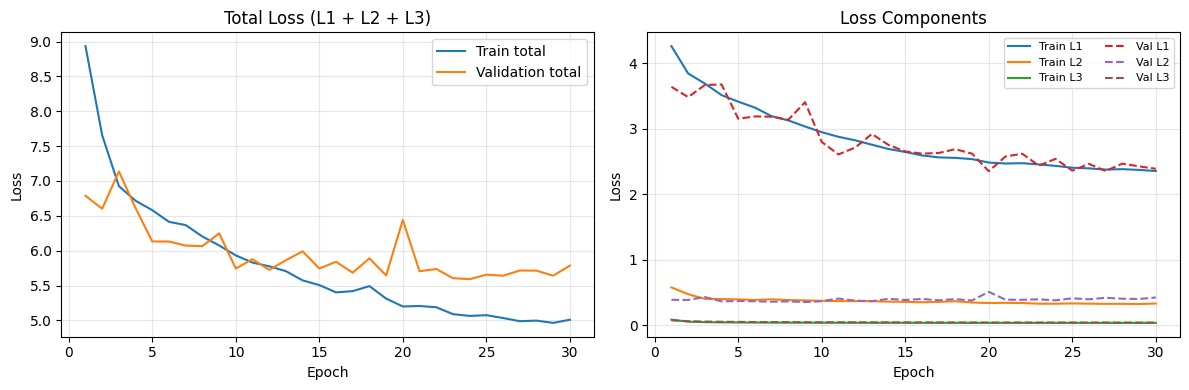

In [24]:
# Compute uninformed (random/prevalence-based) baseline for PR-AUC
y_toxic_val = (D_val == 2).astype(int)
toxic_prevalence_val = float(np.average(y_toxic_val, weights=ORDER_VAL_WEIGHTS))
uninformed_pr_auc = toxic_prevalence_val

if best_params is not None:
    base_net.load_state_dict(best_params)

print(f"Best val weighted CTD {best_val_ctd:.4f} at epoch {best_epoch_idx + 1 if best_epoch_idx is not None else -1}")
print(f"Best val PR-AUC (weighted): {best_val_pr_auc:.4f} (uninformed baseline: {uninformed_pr_auc:.4f})")
job_log("Training stage completed")
gpu_mem_log("Training end")

if wandb_run is not None:
    wandb_run.summary["best_val_ctd"] = float(best_val_ctd)
    wandb_run.summary["best_val_pr_auc"] = float(best_val_pr_auc)
    wandb_run.summary["uninformed_pr_auc_baseline"] = float(uninformed_pr_auc)
    wandb_run.summary["best_epoch"] = int(best_epoch_idx + 1 if best_epoch_idx is not None else -1)

train_losses = train_total_losses
val_losses = val_total_losses

epochs_axis = range(1, len(train_total_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_axis, train_total_losses, label="Train total")
axes[0].plot(epochs_axis, val_total_losses, label="Validation total")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total Loss (L1 + L2 + L3)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_axis, train_l1_losses, label="Train L1")
axes[1].plot(epochs_axis, train_l2_losses, label="Train L2")
axes[1].plot(epochs_axis, train_l3_losses, label="Train L3")
axes[1].plot(epochs_axis, val_l1_losses, linestyle="--", label="Val L1")
axes[1].plot(epochs_axis, val_l2_losses, linestyle="--", label="Val L2")
axes[1].plot(epochs_axis, val_l3_losses, linestyle="--", label="Val L3")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss Components")
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

In [25]:
if wandb_run is not None:
    loss_fig, loss_axes = plt.subplots(1, 2, figsize=(12, 4))

    loss_axes[0].plot(epochs_axis, train_total_losses, label="Train total")
    loss_axes[0].plot(epochs_axis, val_total_losses, label="Validation total")
    loss_axes[0].set_xlabel("Epoch")
    loss_axes[0].set_ylabel("Loss")
    loss_axes[0].set_title("Total Loss (L1 + L2 + L3)")
    loss_axes[0].grid(alpha=0.3)
    loss_axes[0].legend()

    loss_axes[1].plot(epochs_axis, train_l1_losses, label="Train L1")
    loss_axes[1].plot(epochs_axis, train_l2_losses, label="Train L2")
    loss_axes[1].plot(epochs_axis, train_l3_losses, label="Train L3")
    loss_axes[1].plot(epochs_axis, val_l1_losses, linestyle="--", label="Val L1")
    loss_axes[1].plot(epochs_axis, val_l2_losses, linestyle="--", label="Val L2")
    loss_axes[1].plot(epochs_axis, val_l3_losses, linestyle="--", label="Val L3")
    loss_axes[1].set_xlabel("Epoch")
    loss_axes[1].set_ylabel("Loss")
    loss_axes[1].set_title("Loss Components")
    loss_axes[1].grid(alpha=0.3)
    loss_axes[1].legend(fontsize=8, ncol=2)

    loss_fig.tight_layout()

    loss_history_df = pd.DataFrame(
        {
            "epoch": list(epochs_axis),
            "train_total": train_total_losses,
            "val_total": val_total_losses,
            "train_l1": train_l1_losses,
            "train_l2": train_l2_losses,
            "train_l3": train_l3_losses,
            "val_l1": val_l1_losses,
            "val_l2": val_l2_losses,
            "val_l3": val_l3_losses,
        }
    )

    wandb_run.log(
        {
            "plots/loss_curves": wandb.Image(loss_fig),
            "tables/loss_history": wandb.Table(dataframe=loss_history_df),
        }
    )
    plt.close(loss_fig)
    print("Logged loss-curve image and loss-history table to W&B.")
else:
    print("W&B run not active; skipped loss-curve image/table logging.")

Logged loss-curve image and loss-history table to W&B.


## 6. Evaluate Model Performance
### 6a. Predict Cause-Specific CIFs on the Test Set
### 6b. Cause-Specific Concordance

Train/validation use random per-order-instance caps (`MAX_SAMPLES_PER_ORDER`) for efficiency.
Final test evaluation uses full-length trajectories (no per-order cap).

In [26]:
base_net.eval()

n_test = int(test_sample_idx.shape[0])
if n_test <= 0:
    raise RuntimeError("No test samples available for evaluation.")
job_log(f"Evaluation stage started: test_samples={n_test}, batch_size={BATCH_SIZE}")

cif_test = np.empty((NUM_COMPETING_EVENTS, output_steps, n_test), dtype=np.float32)
pred_pin_memory = device.type != "cpu"
total_eval_batches = (n_test + BATCH_SIZE - 1) // BATCH_SIZE
eval_log_every = max(1, total_eval_batches // 10)

with torch.no_grad():
    for start in range(0, n_test, BATCH_SIZE):
        batch_id = (start // BATCH_SIZE) + 1
        if batch_id == 1 or batch_id % eval_log_every == 0 or batch_id == total_eval_batches:
            job_log(f"Evaluation progress: batch {batch_id}/{total_eval_batches}")

        batch_sample_idx = test_sample_idx[start : start + BATCH_SIZE]
        x_b_np, _, _, _, _, _ = materialize_dynamic_samples_from_manifest(
            ORDER_STORE,
            SAMPLE_MANIFEST,
            batch_sample_idx,
        )
        x_b_np = apply_dynamic_normalizer(x_b_np, feat_mean, feat_std)

        x_b = torch.from_numpy(x_b_np).to(device, non_blocking=pred_pin_memory)
        logits_b = base_net(x_b)

        pmf_b = torch.softmax(logits_b.reshape(logits_b.size(0), -1), dim=1).reshape(
            logits_b.size(0),
            NUM_COMPETING_EVENTS,
            output_steps,
        )
        cif_b = torch.cumsum(pmf_b, dim=2).cpu().numpy()  # (B, K, T)

        end = start + cif_b.shape[0]
        cif_test[:, :, start:end] = np.transpose(cif_b, (1, 2, 0))

print(f"CIF array shape: {cif_test.shape} (K, T, N)")
job_log("Evaluation batch inference completed")

ORDER_IDS_TEST = ORDER_IDS_TEST.astype(np.int64)
ORDER_KEYS_TEST = ORDER_KEYS_TEST.astype(np.int64)
UPDATE_IDX_TEST = UPDATE_IDX_TEST.astype(np.int64)

def per_order_instance_weights(order_keys: np.ndarray) -> np.ndarray:
    """Return raw per-instance weights w_i = 1 / V_i (no normalization)."""
    counts = pd.Series(order_keys).value_counts()
    return np.asarray([1.0 / counts[int(order_key)] for order_key in order_keys], dtype=np.float64)

ORDER_TEST_WEIGHTS = per_order_instance_weights(ORDER_KEYS_TEST)

def dynamic_weighted_ctd_event(
    cif_event: np.ndarray,  # (T, N)
    durations: np.ndarray,
    events: np.ndarray,
    event_code: int,
    update_idx: np.ndarray,
    time_grid: np.ndarray,
    instance_weight: np.ndarray,
    eps: float = 1e-12,
) -> float:
    """Weighted dynamic C-td for one event using same-update comparable pairs.

    Comparable set: (i, j) such that
      - event_i == event_code,
      - duration_i < duration_j,
      - update_idx_i == update_idx_j.
    """
    n = len(durations)
    if n == 0:
        return float("nan")

    tau_idx = np.searchsorted(time_grid, durations, side="left")
    tau_idx = np.clip(tau_idx, 0, len(time_grid) - 1)
    # Compare all pairs at a common anchor horizon (tau_i).

    num = 0.0
    den = 0.0

    for step in np.unique(update_idx):
        step_idx = np.where(update_idx == step)[0]
        if step_idx.size <= 1:
            continue

        anchors = step_idx[events[step_idx] == event_code]
        if anchors.size == 0:
            continue

        durations_step = durations[step_idx]
        weights_step = instance_weight[step_idx]

        pos_in_step = {idx: pos for pos, idx in enumerate(step_idx.tolist())}

        for i in anchors:
            i_pos = pos_in_step[int(i)]
            later_mask = durations_step > durations_step[i_pos]
            if not np.any(later_mask):
                continue
            tau_anchor = int(tau_idx[i])
            later_idx = step_idx[later_mask]
            s_i = float(cif_event[tau_anchor, i])
            s_j = cif_event[tau_anchor, later_idx]
            w_pair = weights_step[i_pos] * instance_weight[later_idx]

            concordant = (s_i > s_j).astype(np.float64)
            ties = (s_i == s_j).astype(np.float64)

            num += float(np.sum(w_pair * (concordant + 0.5 * ties)))
            den += float(np.sum(w_pair))

    if den <= eps:
        return float("nan")
    return num / den

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    ctd = dynamic_weighted_ctd_event(
        cif_event=cif_test[k],
        durations=Y_test,
        events=D_test,
        event_code=int(event_code),
        update_idx=UPDATE_IDX_TEST,
        time_grid=time_grid,
        instance_weight=ORDER_TEST_WEIGHTS,
    )
    ctd_scores[event_name] = ctd

macro_ctd = float(np.nanmean(list(ctd_scores.values())))

n_fav_test = int((D_test == 1).sum())
n_tox_test = int((D_test == 2).sum())
n_events_test = n_fav_test + n_tox_test
weighted_ctd = (
    (n_fav_test * ctd_scores.get("FAVORABLE_FILL", np.nan) + n_tox_test * ctd_scores.get("TOXIC_FILL", np.nan)) / n_events_test
    if n_events_test > 0
    else float("nan")
)

print("Weighted dynamic cause-specific C-td (same-update comparable pairs):")
for event_name in EVENT_NAMES:
    print(f"  {event_name:<20}: C-td = {ctd_scores[event_name]:.4f}")
print(f"Macro-average C-td: {macro_ctd:.4f}")
print(f"Weighted C-td: {weighted_ctd:.4f}")
job_log("Evaluation metrics computation completed")

[2026-04-23 06:38:28] Evaluation stage started: test_samples=2597646, batch_size=1024
[2026-04-23 06:38:28] Evaluation progress: batch 1/2537


wandb: WARNING Artifact "run-k2stkuyf-tablesloss_history-GGus0Q" already exists with the same content. No new version will be created.


[2026-04-23 06:39:20] Evaluation progress: batch 253/2537
[2026-04-23 06:40:12] Evaluation progress: batch 506/2537
[2026-04-23 06:41:03] Evaluation progress: batch 759/2537
[2026-04-23 06:41:55] Evaluation progress: batch 1012/2537
[2026-04-23 06:42:47] Evaluation progress: batch 1265/2537
[2026-04-23 06:43:39] Evaluation progress: batch 1518/2537
[2026-04-23 06:44:31] Evaluation progress: batch 1771/2537
[2026-04-23 06:45:23] Evaluation progress: batch 2024/2537
[2026-04-23 06:46:15] Evaluation progress: batch 2277/2537
[2026-04-23 06:47:07] Evaluation progress: batch 2530/2537
[2026-04-23 06:47:09] Evaluation progress: batch 2537/2537
CIF array shape: (2, 30, 2597646) (K, T, N)
[2026-04-23 06:47:09] Evaluation batch inference completed
Weighted dynamic cause-specific C-td (same-update comparable pairs):
  FAVORABLE_FILL      : C-td = 0.7222
  TOXIC_FILL          : C-td = 0.7299
Macro-average C-td: 0.7260
Weighted C-td: 0.7250
[2026-04-23 06:51:30] Evaluation metrics computation comp

In [27]:
if wandb_run is not None:
    ctd_log = {
        "eval/ctd_macro": float(macro_ctd),
        "eval/ctd_weighted": float(weighted_ctd),
    }
    for event_name, ctd_value in ctd_scores.items():
        ctd_log[f"eval/ctd_{event_name.lower()}"] = float(ctd_value)
    wandb_run.log(ctd_log)

    wandb_run.summary["eval_ctd_macro"] = float(macro_ctd)
    wandb_run.summary["eval_ctd_weighted"] = float(weighted_ctd)
    print("Logged C-td metrics to W&B.")
else:
    print("W&B run not active; skipped C-td logging.")

Logged C-td metrics to W&B.


### 6c. Final-Time Probability Distribution (Secondary Sanity Check)

Inspect final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 1953302
  FAVORABLE_FILL: 407070
  TOXIC_FILL    : 237274

Predicted final CIF means at t=232.4s:
  True FAVORABLE -> CIF(FAVORABLE): 0.5068
  True TOXIC     -> CIF(TOXIC)    : 0.5100


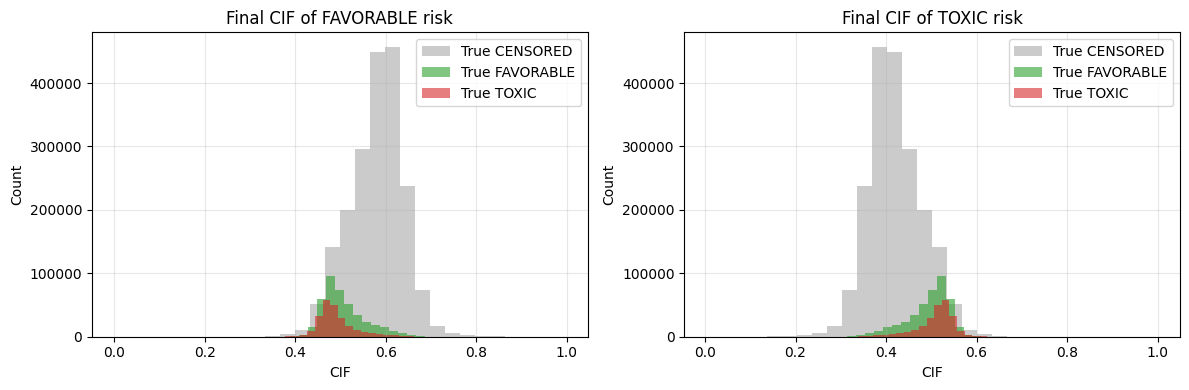

In [28]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
if mask_fav.any():
    print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
if mask_tox.any():
    print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 6d. Weighted Time-Dependent Brier / IBS

Compute weighted time-dependent Brier scores and integrated Brier score (IBS) for each competing event,
using instance weights $w^i = 1/V^i$ so long-lived orders do not dominate evaluation.

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.2375  |  Uninformed = 0.2343
  TOXIC_FILL          : IBS = 0.2406  |  Uninformed = 0.2465
Macro-average IBS: 0.2390
Macro-average IBS (uninformed): 0.2404
Weighted IBS: 0.2386
Weighted IBS (uninformed): 0.2388


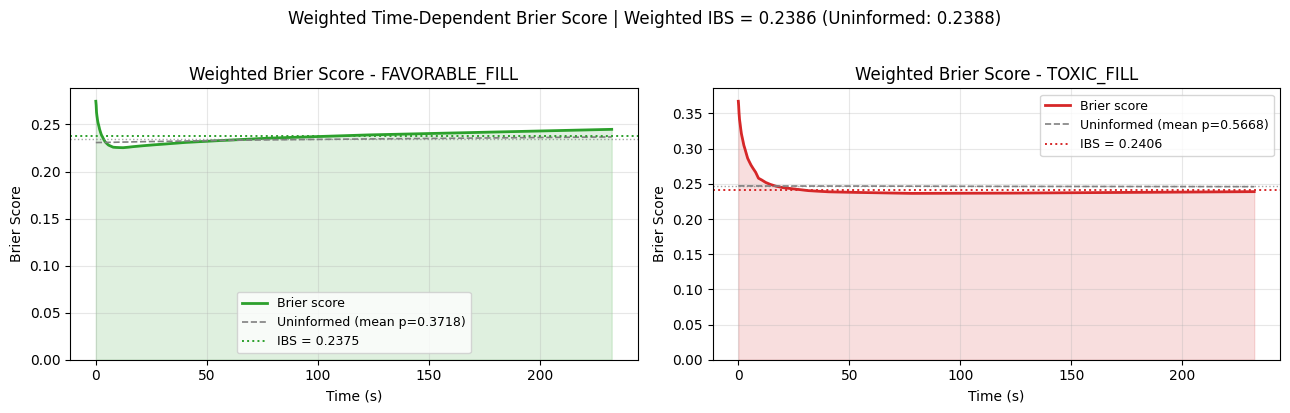

In [29]:
def standard_brier_score_weighted(
    durations: np.ndarray,
    events: np.ndarray,
    cif_k: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
    sample_weight: np.ndarray,
) -> np.ndarray:
    bs = np.zeros(len(time_grid), dtype=np.float64)
    for j, t in enumerate(time_grid):
        y_t = ((events == event_code) & (durations <= t)).astype(np.float64)
        err = (y_t - cif_k[j]) ** 2
        bs[j] = np.average(err, weights=sample_weight)
    return bs

def uninformed_cif_curve_from_train_weighted(
    durations_train: np.ndarray,
    events_train: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
    sample_weight_train: np.ndarray,
) -> np.ndarray:
    probs = np.zeros(len(time_grid), dtype=np.float64)
    for j, t in enumerate(time_grid):
        y_t = ((events_train == event_code) & (durations_train <= t)).astype(np.float64)
        probs[j] = np.average(y_t, weights=sample_weight_train)
    return probs

def uninformed_brier_score_weighted(
    durations: np.ndarray,
    events: np.ndarray,
    p_event_curve: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
    sample_weight: np.ndarray,
) -> np.ndarray:
    bs = np.zeros(len(time_grid), dtype=np.float64)
    for j, t in enumerate(time_grid):
        y_t = ((events == event_code) & (durations <= t)).astype(np.float64)
        err = (y_t - p_event_curve[j]) ** 2
        bs[j] = np.average(err, weights=sample_weight)
    return bs

def integrated_brier_score_to_tmax(
    bs_curve: np.ndarray,
    time_grid: np.ndarray,
    t_max: float,
) -> float:
    """Compute IBS_k = (1 / T_max) * integral_0^{T_max} BS_k^{td}(t) dt."""
    if t_max <= 0:
        return float("nan")

    t_grid = np.asarray(time_grid, dtype=np.float64)
    bs_arr = np.asarray(bs_curve, dtype=np.float64)
    if t_grid.size == 0 or bs_arr.size == 0:
        return float("nan")

    # The formal definition integrates from t=0. If the discrete grid starts
    # above zero, prepend BS(0)=0 (CIF(0)=0 and no event can occur before t=0).
    if t_grid[0] > 0.0:
        t_eval = np.concatenate(([0.0], t_grid))
        bs_eval = np.concatenate(([0.0], bs_arr))
    else:
        t_eval = t_grid
        bs_eval = bs_arr

    _trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz
    return float(_trapz(bs_eval, t_eval) / t_max)

def per_order_instance_weights(order_keys: np.ndarray) -> np.ndarray:
    """Return raw per-instance weights w_i = 1 / V_i (no normalization)."""
    counts = pd.Series(order_keys).value_counts()
    return np.asarray([1.0 / counts[int(order_key)] for order_key in order_keys], dtype=np.float64)

ORDER_TRAIN_WEIGHTS = per_order_instance_weights(ORDER_KEYS_TRAIN)

p_fav_train_curve = uninformed_cif_curve_from_train_weighted(
    Y_train,
    D_train,
    1,
    time_grid,
    ORDER_TRAIN_WEIGHTS,
)
p_tox_train_curve = uninformed_cif_curve_from_train_weighted(
    Y_train,
    D_train,
    2,
    time_grid,
    ORDER_TRAIN_WEIGHTS,
)

bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score_weighted(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
        sample_weight=ORDER_TEST_WEIGHTS,
    )

bs_curves_uninformed = {
    "FAVORABLE_FILL": uninformed_brier_score_weighted(
        Y_test, D_test, p_fav_train_curve, 1, time_grid, ORDER_TEST_WEIGHTS
    ),
    "TOXIC_FILL": uninformed_brier_score_weighted(
        Y_test, D_test, p_tox_train_curve, 2, time_grid, ORDER_TEST_WEIGHTS
    ),
}

T_MAX_EVAL = float(time_grid[-1])

ibs_scores = {}
ibs_scores_uninformed = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = integrated_brier_score_to_tmax(bs_arr, time_grid, T_MAX_EVAL)
    ibs_scores_uninformed[event_name] = integrated_brier_score_to_tmax(bs_curves_uninformed[event_name], time_grid, T_MAX_EVAL)

macro_ibs = float(np.mean(list(ibs_scores.values())))
macro_ibs_uninformed = float(np.mean(list(ibs_scores_uninformed.values())))

n_fav_test = int((D_test == 1).sum())
n_tox_test = int((D_test == 2).sum())
n_events_test = n_fav_test + n_tox_test
weighted_ibs = (
    (n_fav_test * ibs_scores["FAVORABLE_FILL"] + n_tox_test * ibs_scores["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else float("nan")
)
weighted_ibs_uninformed = (
    (n_fav_test * ibs_scores_uninformed["FAVORABLE_FILL"] + n_tox_test * ibs_scores_uninformed["TOXIC_FILL"]) / n_events_test
    if n_events_test > 0
    else float("nan")
)

print("Integrated Brier Score (IBS) per event:")
for event_name in EVENT_NAMES:
    print(
        f"  {event_name:<20}: IBS = {ibs_scores[event_name]:.4f}  |  Uninformed = {ibs_scores_uninformed[event_name]:.4f}"
    )
print(f"Macro-average IBS: {macro_ibs:.4f}")
print(f"Macro-average IBS (uninformed): {macro_ibs_uninformed:.4f}")
print(f"Weighted IBS: {weighted_ibs:.4f}")
print(f"Weighted IBS (uninformed): {weighted_ibs_uninformed:.4f}")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, event_name in zip(axes, EVENT_NAMES):
    bs_arr = bs_curves[event_name]
    ibs_val = ibs_scores[event_name]
    ibs_uninf_val = ibs_scores_uninformed[event_name]
    color = colors_bs.get(event_name, "#1f77b4")
    baseline_curve = p_fav_train_curve if event_name == "FAVORABLE_FILL" else p_tox_train_curve

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.plot(
        time_grid,
        bs_curves_uninformed[event_name],
        color="grey",
        linestyle="--",
        linewidth=1.2,
        label=f"Uninformed (mean p={baseline_curve.mean():.4f})",
    )
    ax.axhline(ibs_uninf_val, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Weighted Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(
    f"Weighted Time-Dependent Brier Score | Weighted IBS = {weighted_ibs:.4f} (Uninformed: {weighted_ibs_uninformed:.4f})",
    fontsize=12,
    y=1.02,
)
plt.tight_layout()
plt.show()

In [30]:
wandb_active = wandb_run is not None and not bool(getattr(wandb_run, "_is_finished", False))
if wandb_active:
    ibs_log = {
        "eval/ibs_macro": float(macro_ibs),
        "eval/ibs_macro_uninformed": float(macro_ibs_uninformed),
        "eval/ibs_weighted": float(weighted_ibs),
        "eval/ibs_weighted_uninformed": float(weighted_ibs_uninformed),
    }
    for event_name in EVENT_NAMES:
        ibs_log[f"eval/ibs_{event_name.lower()}"] = float(ibs_scores[event_name])
        ibs_log[f"eval/ibs_{event_name.lower()}_uninformed"] = float(ibs_scores_uninformed[event_name])
    wandb_run.log(ibs_log)

    wandb_run.summary["eval_ibs_weighted"] = float(weighted_ibs)
    wandb_run.summary["eval_ibs_macro"] = float(macro_ibs)
    print("Logged IBS metrics to W&B.")
else:
    print("W&B run not active (missing or finished); skipped IBS logging.")

Logged IBS metrics to W&B.


### 6e. Terminal State Classification (Weighted PR-AUC)

Primary terminal classification metric under imbalance is weighted PR-AUC using the minority-class score
$\hat{\mathcal{F}}_{\text{TOXIC}}(T_{\max}\mid\mathcal{X}^i)$ and instance weights $w^i = 1/V^i$.

We report weighted PR-AUC as primary and weighted ROC-AUC as a secondary sanity check.

Terminal minority-class classification (TOXIC_FILL):
  Weighted PR-AUC (primary): 0.6502
  Sample-level PR-AUC      : 0.2731
  Weighted ROC-AUC (secondary): 0.6321
  Sample-level ROC-AUC        : 0.8364
  Weighted toxic prevalence baseline: 0.5648
  Sample toxic prevalence baseline  : 0.0913


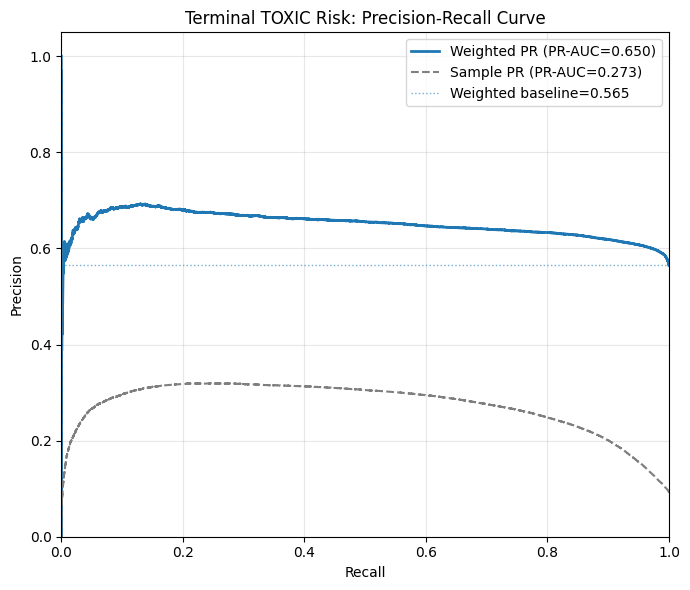


DYNAMIC MODEL METRICS SUMMARY
Best_Val_Loss             : 5.5917
Best_Epoch                : 24
Favorable_Ctd             : 0.7222
Toxic_Ctd                 : 0.7299
Weighted_Ctd              : 0.7250
Toxic_PR_AUC_Weighted     : 0.6502
Toxic_PR_AUC_Sample       : 0.2731
Toxic_ROC_AUC_Weighted    : 0.6321
Weighted_IBS              : 0.2386
Total_Params              : 264,973


In [31]:
from sklearn.metrics import auc, precision_recall_curve, roc_auc_score

# Terminal scores
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# Minority class: TOXIC_FILL (code=2)
y_true = D_test.astype(int)
y_toxic = (y_true == 2).astype(int)

def safe_pr_auc_binary(
    y_true_binary: np.ndarray,
    y_score: np.ndarray,
    sample_weight: np.ndarray | None = None,
) -> tuple[float, np.ndarray, np.ndarray]:
    """Compute PR-AUC = integral_0^1 Precision(recall) d(recall)."""
    if int(y_true_binary.sum()) == 0:
        return float("nan"), np.array([1.0], dtype=np.float64), np.array([0.0], dtype=np.float64)
    precision, recall, _ = precision_recall_curve(
        y_true_binary,
        y_score,
        sample_weight=sample_weight,
    )
    # sklearn returns recall in decreasing order; reverse for auc integration.
    pr_auc = float(auc(recall[::-1], precision[::-1]))
    return pr_auc, precision, recall

def safe_roc_auc_binary(y_true_binary: np.ndarray, y_score: np.ndarray, sample_weight: np.ndarray | None = None) -> float:
    if np.unique(y_true_binary).size < 2:
        return float("nan")
    return float(roc_auc_score(y_true_binary, y_score, sample_weight=sample_weight))

ap_toxic_weighted, precision_w, recall_w = safe_pr_auc_binary(
    y_toxic,
    final_cif_tox,
    sample_weight=ORDER_TEST_WEIGHTS,
)
ap_toxic_sample, precision_s, recall_s = safe_pr_auc_binary(y_toxic, final_cif_tox)

auc_toxic_weighted = safe_roc_auc_binary(y_toxic, final_cif_tox, sample_weight=ORDER_TEST_WEIGHTS)
auc_toxic_sample = safe_roc_auc_binary(y_toxic, final_cif_tox)

toxic_prevalence_weighted = float(np.average(y_toxic, weights=ORDER_TEST_WEIGHTS))
toxic_prevalence_sample = float(np.mean(y_toxic))

print("Terminal minority-class classification (TOXIC_FILL):")
print(f"  Weighted PR-AUC (primary): {ap_toxic_weighted:.4f}")
print(f"  Sample-level PR-AUC      : {ap_toxic_sample:.4f}")
print(f"  Weighted ROC-AUC (secondary): {auc_toxic_weighted:.4f}")
print(f"  Sample-level ROC-AUC        : {auc_toxic_sample:.4f}")
print(f"  Weighted toxic prevalence baseline: {toxic_prevalence_weighted:.4f}")
print(f"  Sample toxic prevalence baseline  : {toxic_prevalence_sample:.4f}")

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_w, precision_w, color="#1f77b4", lw=2, label=f"Weighted PR (PR-AUC={ap_toxic_weighted:.3f})")
ax.plot(recall_s, precision_s, color="#7f7f7f", lw=1.5, linestyle="--", label=f"Sample PR (PR-AUC={ap_toxic_sample:.3f})")
ax.hlines(
    toxic_prevalence_weighted,
    xmin=0,
    xmax=1,
    colors="#1f77b4",
    linestyles=":",
    linewidth=1,
    alpha=0.6,
    label=f"Weighted baseline={toxic_prevalence_weighted:.3f}",
)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Terminal TOXIC Risk: Precision-Recall Curve")
ax.grid(alpha=0.3)
ax.legend(loc="best")
plt.tight_layout()
plt.show()

metrics_summary = {
    "Best_Val_Loss": f"{best_val_loss:.4f}" if best_val_loss is not None else "N/A",
    "Best_Epoch": best_epoch_idx + 1 if best_epoch_idx is not None else "N/A",
    "Favorable_Ctd": f"{ctd_scores.get('FAVORABLE_FILL', np.nan):.4f}",
    "Toxic_Ctd": f"{ctd_scores.get('TOXIC_FILL', np.nan):.4f}",
    "Weighted_Ctd": f"{weighted_ctd:.4f}",
    "Toxic_PR_AUC_Weighted": f"{ap_toxic_weighted:.4f}",
    "Toxic_PR_AUC_Sample": f"{ap_toxic_sample:.4f}",
    "Toxic_ROC_AUC_Weighted": f"{auc_toxic_weighted:.4f}",
    "Weighted_IBS": f"{weighted_ibs:.4f}" if "weighted_ibs" in globals() else "N/A",
    "Total_Params": f"{total_params:,}",
}

print("\n" + "=" * 70)
print("DYNAMIC MODEL METRICS SUMMARY")
print("=" * 70)
for key, value in metrics_summary.items():
    print(f"{key:<25} : {value}")
print("=" * 70)

In [32]:
wandb_active = wandb_run is not None and not bool(getattr(wandb_run, "_is_finished", False))
if wandb_active:
    pr_log = {
        "eval/toxic_pr_auc_weighted": float(ap_toxic_weighted),
        "eval/toxic_pr_auc_sample": float(ap_toxic_sample),
        "eval/toxic_roc_auc_weighted": float(auc_toxic_weighted),
        "eval/toxic_roc_auc_sample": float(auc_toxic_sample),
        "eval/toxic_prevalence_weighted": float(toxic_prevalence_weighted),
        "eval/toxic_prevalence_sample": float(toxic_prevalence_sample),
    }
    wandb_run.log(pr_log)

    for key, value in metrics_summary.items():
        try:
            wandb_run.summary[f"summary/{key}"] = float(value)
        except Exception:
            wandb_run.summary[f"summary/{key}"] = str(value)
    print("Logged PR-AUC/ROC-AUC metrics and summary table to W&B.")
else:
    print("W&B run not active (missing or finished); skipped PR-AUC logging.")

Logged PR-AUC/ROC-AUC metrics and summary table to W&B.


## 7. Save Model Artifacts

In [33]:
import io

# Common metadata for both best and last models.
metadata = {
    "model_name": MODEL_NAME,
    "framework": "dynamic_deephit",
    "num_competing_events": NUM_COMPETING_EVENTS,
    "event_names": EVENT_NAMES,
    "output_steps": output_steps,
    "time_grid": time_grid,
    "lookback_steps": LOOKBACK_STEPS,
    "rolling_lookback_window": True,
    "order_balanced_training": True,
    "num_train_orders": int(len(np.unique(ORDER_KEYS_TRAIN))),
    "num_val_orders": int(len(np.unique(ORDER_KEYS_VAL))),
    "num_test_orders": int(len(np.unique(ORDER_KEYS_TEST))),
    "num_train_unique_order_ids": int(len(np.unique(ORDER_IDS_TRAIN))),
    "num_val_unique_order_ids": int(len(np.unique(ORDER_IDS_VAL))),
    "num_test_unique_order_ids": int(len(np.unique(ORDER_IDS_TEST))),
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch_idx + 1 if best_epoch_idx is not None else None,
    "best_val_loss": best_val_loss,
}


def _artifact_add_bytes(artifact, artifact_path: str, payload: bytes) -> None:
    # wandb.Artifact.add_file expects a filesystem path; use new_file for in-memory bytes.
    with artifact.new_file(artifact_path, mode="wb") as f:
        f.write(payload)


wandb_active = wandb_run is not None and not bool(getattr(wandb_run, "_is_finished", False))

if wandb_active:
    job_log("Uploading model artifacts to W&B...")

    # Get W&B run ID for unique artifact naming.
    run_id = wandb_run.id

    # Serialize best-epoch model and metadata into in-memory bytes.
    best_model_bytes = io.BytesIO()
    if best_params is not None:
        torch.save(best_params, best_model_bytes)
    else:
        torch.save(base_net.state_dict(), best_model_bytes)
    best_model_payload = best_model_bytes.getvalue()

    best_meta_bytes = io.BytesIO()
    torch.save(metadata, best_meta_bytes)
    best_meta_payload = best_meta_bytes.getvalue()

    # Serialize last-epoch model (current base_net state) and metadata.
    last_model_bytes = io.BytesIO()
    torch.save(base_net.state_dict(), last_model_bytes)
    last_model_payload = last_model_bytes.getvalue()

    last_meta_bytes = io.BytesIO()
    last_metadata = metadata.copy()
    last_metadata["checkpoint_type"] = "last_epoch"
    torch.save(last_metadata, last_meta_bytes)
    last_meta_payload = last_meta_bytes.getvalue()

    # Upload best-epoch model artifact.
    best_epoch_num = best_epoch_idx + 1 if best_epoch_idx is not None else 0
    artifact_best = wandb.Artifact(
        name=f"best_epoch_model_e{best_epoch_num}_{run_id}",
        type="model",
    )
    _artifact_add_bytes(
        artifact_best,
        artifact_path=f"dynamic_deephit_{MODEL_NAME}_{TICKER}_best_epoch_base_net_{run_id}.pt",
        payload=best_model_payload,
    )
    wandb_run.log_artifact(artifact_best)

    # Upload best-epoch metadata artifact.
    artifact_best_meta = wandb.Artifact(
        name=f"best_epoch_metadata_e{best_epoch_num}_{run_id}",
        type="metadata",
    )
    _artifact_add_bytes(
        artifact_best_meta,
        artifact_path=f"dynamic_deephit_{MODEL_NAME}_{TICKER}_best_epoch_meta_{run_id}.pt",
        payload=best_meta_payload,
    )
    wandb_run.log_artifact(artifact_best_meta)
    best_loss_str = f"{best_val_loss:.4f}" if best_val_loss is not None else "N/A"
    job_log(f"Best-epoch model and metadata uploaded to W&B (epoch {best_epoch_num}; loss={best_loss_str}; run_id={run_id})")

    # Upload last-epoch model artifact.
    artifact_last = wandb.Artifact(
        name=f"last_epoch_model_e{NUM_EPOCHS}_{run_id}",
        type="model",
    )
    _artifact_add_bytes(
        artifact_last,
        artifact_path=f"dynamic_deephit_{MODEL_NAME}_{TICKER}_last_epoch_base_net_{run_id}.pt",
        payload=last_model_payload,
    )
    wandb_run.log_artifact(artifact_last)

    # Upload last-epoch metadata artifact.
    artifact_last_meta = wandb.Artifact(
        name=f"last_epoch_metadata_e{NUM_EPOCHS}_{run_id}",
        type="metadata",
    )
    _artifact_add_bytes(
        artifact_last_meta,
        artifact_path=f"dynamic_deephit_{MODEL_NAME}_{TICKER}_last_epoch_meta_{run_id}.pt",
        payload=last_meta_payload,
    )
    wandb_run.log_artifact(artifact_last_meta)
    job_log(f"Last-epoch model and metadata uploaded to W&B (epoch {NUM_EPOCHS}; run_id={run_id})")

    wandb_run.summary["models_uploaded_to_wandb"] = True
    wandb_run.finish()
    job_log("W&B run finished.")
else:
    print("W&B run not active; skipped model upload.")

[2026-04-23 06:51:40] Uploading model artifacts to W&B...
[2026-04-23 06:51:41] Best-epoch model and metadata uploaded to W&B (epoch 24; loss=5.5917; run_id=k2stkuyf)
[2026-04-23 06:51:41] Last-epoch model and metadata uploaded to W&B (epoch 30; run_id=k2stkuyf)


eval/ctd_favorable_fill,▁
eval/ctd_macro,▁
eval/ctd_toxic_fill,▁
eval/ctd_weighted,▁
eval/ibs_favorable_fill,▁
eval/ibs_favorable_fill_uninformed,▁
eval/ibs_macro,▁
eval/ibs_macro_uninformed,▁
eval/ibs_toxic_fill,▁
eval/ibs_toxic_fill_uninformed,▁
+8,...


[2026-04-23 06:51:45] W&B run finished.
